# The dataset, seen

Section 3.1 (*Problem Setting*). The eleven pipelines of this study are trained on the
same $8{,}100$ transient methane fields, and every error reported later is an error on
*these* fields — yet the article shows none of them. This notebook produces the three
figures that fix that: what a simulation looks like in time, what each of the three
parameters $(k, \phi, C)$ does to it, and how the design of experiments is laid out.

It reads `dataset/ch4_rotated.npy` (8100, 150, 128, 128) through a memory map and never
holds more than a few simulations at a time; no model, no checkpoint, no GPU.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
# Article figure style; `run` prefixes the output filenames.
import figstyle
figstyle.setup(run='data')       # titles=True pour garder les suptitle en interactif

figstyle: style=paper.mplstyle  run=data  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Configuration

The fields are the methane mass fraction $Y$ on the $128 \times 128$ centre crop, over the
$N_t = 150$ nodes of the $\Delta t = 1$ s grid. `doe_rotated.npy` carries one
$(k, \phi, C)$ triple per instance, the angle stored under the field name `A`.

In [3]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'

DT     = 1.0            # s
CMAP   = 'gist_heat_r'  # sequential, white at zero, monotone luminance (greyscale-safe)
SCALE  = 1e2            # fields are plotted in units of 1e-2, so no exponent label
N_ANG  = 36             # rotations per base simulation

U   = np.load(DATA_PATH, mmap_mode='r')      # (8100, 150, 128, 128) float32
doe = np.load(DOE_PATH)                      # structured (k, A, C)

K_VALS = np.unique(doe['k'])                 # 15 diffusion values
C_VALS = np.unique(doe['C'])                 # 15 injection rates
A_VALS = np.unique(doe['A'])                 # 36 angles

ns, Nt, N, _ = U.shape
print(f'U   {U.shape}  {U.dtype}   ({U.nbytes / 1e9:.1f} GB on disk, memory-mapped)')
print(f'k   {len(K_VALS)} values in [{K_VALS.min():.3g}, {K_VALS.max():.3g}]')
print(f'C   {len(C_VALS)} values in [{C_VALS.min():.3g}, {C_VALS.max():.3g}] kg/m3/s')
print(f'phi {len(A_VALS)} values, step {A_VALS[1] - A_VALS[0]:.0f} deg')

split = np.load(SPLIT_PATH)
print(f'split: {len(split["train_idx"])} train+val / {len(split["test_idx"])} test')

U   (8100, 150, 128, 128)  float32   (79.6 GB on disk, memory-mapped)
k   15 values in [0.1, 1]
C   15 values in [0.005, 0.02] kg/m3/s
phi 36 values, step 10 deg
split: 6480 train+val / 1620 test


The instances are laid out by construction (`utils/rotate.py`): base simulation
$b = 15\,i_k + i_C$ is replicated over the $36$ angles, so instance $36\,b + i_\phi$
carries $(k_{i_k},\ 10 i_\phi{}^\circ,\ C_{i_C})$. The assertion below is what lets the
rest of the notebook index by parameter value instead of searching for it.

In [4]:
def sim_index(ik, iC, iphi=0):
    # Instance index for a (k, C, phi) grid position -- layout from utils/rotate.py.
    return int((ik * len(C_VALS) + iC) * N_ANG + iphi)


for ik in (0, 7, 14):
    for iC in (0, 7, 14):
        for iphi in (0, 9, 35):
            j = sim_index(ik, iC, iphi)
            assert np.isclose(doe['k'][j], K_VALS[ik])
            assert np.isclose(doe['C'][j], C_VALS[iC])
            assert np.isclose(doe['A'][j], A_VALS[iphi])
print('layout check: ok')

layout check: ok


## 2. What a transient looks like

The transient has two regimes: the plume grows and spreads from the injection point until
$t \approx 70$ s, then decays back to zero, essentially extinct by $t \approx 110$ s. That
the signal returns to zero inside the window is what makes the finite-horizon Laplace
transform of Section 2.1 well posed, and it is worth seeing before reading any error table.

One row per corner of the parameter box, six times each. The colour scale is shared along
a row and reset between rows: the amplitude varies by a factor of three across $C$, and a
single scale would flatten the first row to white.

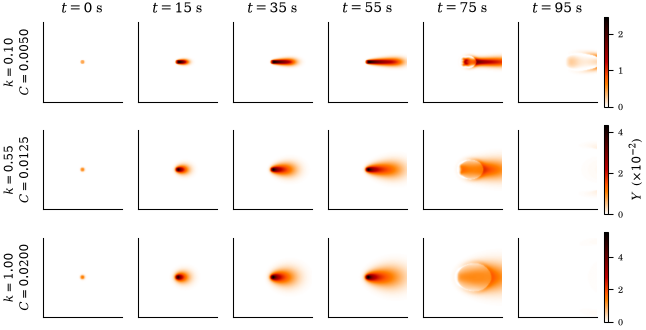

  ↳ article/images/data_snapshots.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/data_snapshots.pdf')

In [5]:
# Three instances spanning the box: weak, mid, strong.
ROWS = [
    dict(ik=0,  iC=0,  iphi=0),
    dict(ik=7,  iC=7,  iphi=0),
    dict(ik=14, iC=14, iphi=0),
]
TIMES = [0, 15, 35, 55, 75, 95]         # time-step indices, dt = 1 s

fig, axes = plt.subplots(len(ROWS), len(TIMES), figsize=(6.7, 3.6))

for r, cfg in enumerate(ROWS):
    j = sim_index(**cfg)
    frames = np.asarray(U[j][TIMES]) * SCALE         # (6, N, N), in units of 1e-2
    vmax = float(frames.max())
    for c, t in enumerate(TIMES):
        ax = axes[r, c]
        im = ax.imshow(frames[c], cmap=CMAP, origin='lower', vmin=0.0, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0:
            ax.set_title(f'$t = {t * DT:.0f}$ s')
    axes[r, 0].set_ylabel(f'$k={doe["k"][j]:.2f}$\n$C={doe["C"][j]:.4f}$',
                          fontsize=8, labelpad=6)
    cb = fig.colorbar(im, ax=list(axes[r]), fraction=0.018, pad=0.012)
    cb.ax.tick_params(labelsize=6)
    if r == len(ROWS) // 2:
        cb.set_label(r'$Y$  ($\times 10^{-2}$)', fontsize=8)

fig.suptitle('Methane mass fraction Y - transient at three points of the parameter box')
plt.show()
figstyle.save('snapshots')

## 3. What each parameter does

Same time $t = 60$ s, one row per parameter, the other two held at the centre of the grid.
The diffusion $k$ sets how far the plume has spread, the injection rate $C$ scales its
amplitude almost linearly — hence the shared colour scale along that row — and the angle
$\phi$ rotates it rigidly, which is the geometric replication described in the text rather
than an independent solve.

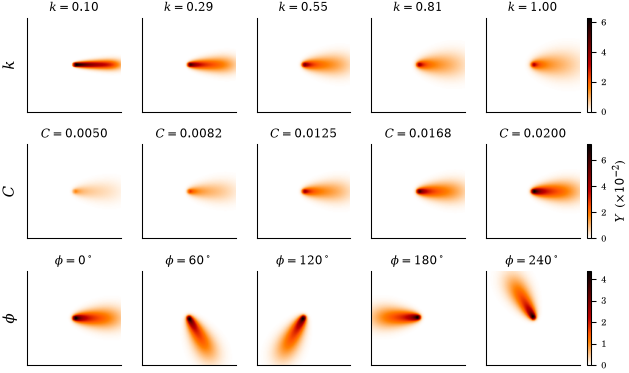

  ↳ article/images/data_params.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/data_params.pdf')

In [6]:
T_SHOW = 60                                  # time-step index
SEL    = [0, 3, 7, 11, 14]                   # 5 values out of the 15-point grids
IPHI   = [0, 6, 12, 18, 24]                  # 0, 60, 120, 180, 240 degrees

sweeps = [
    ('$k$',    [sim_index(ik, 7, 0) for ik in SEL],
               [f'$k={K_VALS[ik]:.2f}$' for ik in SEL]),
    ('$C$',    [sim_index(7, iC, 0) for iC in SEL],
               [f'$C={C_VALS[iC]:.4f}$' for iC in SEL]),
    (r'$\phi$', [sim_index(7, 7, ip) for ip in IPHI],
               [rf'$\phi={A_VALS[ip]:.0f}^\circ$' for ip in IPHI]),
]

fig, axes = plt.subplots(len(sweeps), len(SEL), figsize=(6.7, 4.1))
fig.subplots_adjust(hspace=0.35)

for r, (name, idxs, titles) in enumerate(sweeps):
    frames = np.stack([np.asarray(U[j][T_SHOW]) for j in idxs]) * SCALE
    vmax = float(frames.max())
    for c in range(len(idxs)):
        ax = axes[r, c]
        im = ax.imshow(frames[c], cmap=CMAP, origin='lower', vmin=0.0, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(titles[c], fontsize=8, pad=4)
    axes[r, 0].set_ylabel(name, fontsize=10, labelpad=6)
    cb = fig.colorbar(im, ax=list(axes[r]), fraction=0.018, pad=0.012)
    cb.ax.tick_params(labelsize=6)
    if r == len(sweeps) // 2:
        cb.set_label(r'$Y$  ($\times 10^{-2}$)', fontsize=8)

fig.suptitle(f'Effect of each parameter at t = {T_SHOW * DT:.0f} s')
plt.show()
figstyle.save('params')

## 4. The design of experiments, and the shape of the transients

The sweep is a full $15 \times 15$ tensor grid on $(k, C)$, each node replicated at $36$
angles. The two right-hand panels track $\|Y(t)\|_2$ over the whole window: $C$ scales the
curve, $k$ moves and flattens its peak, and every instance collapses back to zero well
inside the horizon.

In [7]:
# Full curves: 15 simulations per sweep, read once each (about 10 MB per simulation).
def norm_curve(j):
    u = np.asarray(U[j], dtype=np.float64)
    return np.linalg.norm(u.reshape(Nt, -1), axis=1)


t_axis   = np.arange(Nt) * DT
curves_k = np.stack([norm_curve(sim_index(ik, 7, 0)) for ik in range(len(K_VALS))])
curves_C = np.stack([norm_curve(sim_index(7, iC, 0)) for iC in range(len(C_VALS))])
print('curves computed:', curves_k.shape, curves_C.shape)

curves computed: (15, 150) (15, 150)


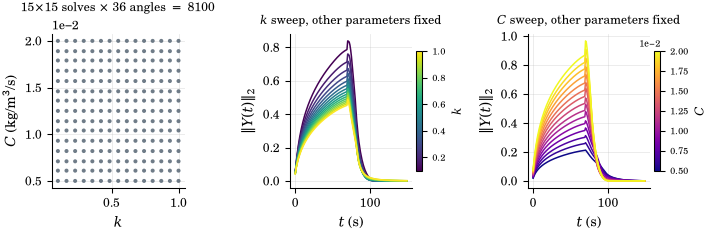

  ↳ article/images/data_dynamics.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/data_dynamics.pdf')

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(6.7, 2.35))

# (a) design of experiments
ax = axes[0]
kk, cc = np.meshgrid(K_VALS, C_VALS, indexing='ij')
ax.scatter(kk.ravel(), cc.ravel(), s=7, color=figstyle.PALETTE['pod'],
           edgecolor='none', alpha=0.85)
ax.set_xlabel('$k$')
ax.set_ylabel('$C$ (kg/m$^3$/s)')
ax.set_title(rf'{len(K_VALS)}$\times${len(C_VALS)} solves $\times$ {N_ANG} angles '
             rf'$=$ {len(doe)}', fontsize=8)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# (b, c) transient shape along each sweep
for ax, curves, vals, name, cmap in [
    (axes[1], curves_k, K_VALS, '$k$', 'viridis'),
    (axes[2], curves_C, C_VALS, '$C$', 'plasma'),
]:
    norm = Normalize(vmin=float(vals.min()), vmax=float(vals.max()))
    sm = ScalarMappable(norm=norm, cmap=cmap)
    for v, y in zip(vals, curves):
        ax.plot(t_axis, y, color=sm.to_rgba(v), lw=1.0)
    ax.set_xlabel('$t$ (s)')
    ax.set_ylabel(r'$\|Y(t)\|_2$')
    cb = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label(name, fontsize=8)
    cb.ax.tick_params(labelsize=6)
    cb.formatter.set_powerlimits((0, 0))
    cb.update_ticks()
    cb.ax.yaxis.get_offset_text().set_fontsize(6)
    ax.set_title(f'{name} sweep, other parameters fixed', fontsize=8)

fig.suptitle('Design of experiments and transient shape')
fig.tight_layout()
plt.show()
figstyle.save('dynamics')

In [9]:
figstyle.summary()

figstyle: 3 figure(s) in /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images
  data_snapshots.pdf
  data_params.pdf
  data_dynamics.pdf
